# Etapa 2: CNN Profunda desde Cero

**Objetivo**: Diseñar, entrenar y evaluar una red neuronal convolucional (CNN) profunda construida desde cero para la clasificación de defectos en piel de aeronaves.

**Contenido**:
1. Setup e importaciones
2. Carga de datos con DataLoaders (imágenes RGB, 224×224)
3. CNN de 4 bloques (arquitectura base)
4. CNN de 6 bloques (más profunda) — Ablation Study
5. Ablation Study: efecto de capas, dropout, learning rate
6. Evaluación comparativa CNN vs MLP
7. Visualización con Grad-CAM
8. Conclusiones

## 1. Setup e Importaciones

In [1]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.data_utils import (
    get_dataloaders, get_transforms, CLASS_NAMES,
    get_class_weights, IMAGENET_MEAN, IMAGENET_STD,
)
from src.models import CNNClassifier, CNNClassifierDeep, count_parameters, get_model
from src.train import train_classifier
from src.evaluate import (
    compute_metrics, get_predictions_with_proba,
    plot_confusion_matrix, plot_training_history,
    plot_roc_curves, plot_model_comparison, print_comparison_table,
)
from src.gradcam import generate_gradcam, plot_gradcam, get_target_layer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = PROJECT_ROOT / "results" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device: {DEVICE}")
print(f"Project root: {PROJECT_ROOT}")

Device: cuda
Project root: d:\Documents\Maestria\ML\aircraft-skin-defect-classifier


## 2. Carga de Datos

In [2]:
splits_dir = PROJECT_ROOT / "data" / "splits"
class_weights = get_class_weights(splits_dir / "train.csv")

train_loader, val_loader, test_loader = get_dataloaders(
    splits_dir=splits_dir,
    img_size=224,
    batch_size=32,
    num_workers=2,
    augment_train=True,
)

print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}")
print(f"Class weights: {class_weights}")

Train: 23730 | Val: 5085 | Test: 5086
Class weights: tensor([0.8376, 0.6737, 0.9028, 1.0074, 4.5157])


## 3. CNN Base (4 bloques convolucionales)

Arquitectura: 4 × (Conv3×3 → BatchNorm → ReLU → MaxPool2×2) + GlobalAvgPool + FC(256 → 5)
- Preserva estructura espacial (a diferencia del MLP)
- Parámetros compartidos vía kernels convolucionales
- Pooling reduce dimensiones gradualmente

In [3]:
cnn_model = CNNClassifier(num_classes=5, dropout=0.5)
cnn_params = count_parameters(cnn_model)
print(f"CNN Base (4 bloques):")
print(f"  Parametros totales:     {cnn_params['total']:,}")
print(f"  Parametros entrenables: {cnn_params['trainable']:,}")
print(f"\nArquitectura:\n{cnn_model}")

CNN Base (4 bloques):
  Parametros totales:     456,453
  Parametros entrenables: 456,453

Arquitectura:
CNNClassifier(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm

In [4]:
history_cnn = train_classifier(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=40,
    lr=1e-3,
    weight_decay=1e-4,
    class_weights=class_weights,
    device=DEVICE,
    save_dir=MODELS_DIR,
    model_name="cnn_base",
    patience=10,
    scheduler_type="cosine",
)

Epoch   1/40 | Train Loss: 1.4626 Acc: 0.3467 | Val Loss: 1.3986 Acc: 0.3536 | LR: 1.00e-03 | 1562.4s
  Mejor modelo guardado (val_acc=0.3536)


Epoch   2/40 | Train Loss: 1.3876 Acc: 0.3933 | Val Loss: 1.3673 Acc: 0.4045 | LR: 9.98e-04 | 305.9s
  Mejor modelo guardado (val_acc=0.4045)


Epoch   3/40 | Train Loss: 1.3446 Acc: 0.4108 | Val Loss: 1.3096 Acc: 0.4234 | LR: 9.94e-04 | 385.9s
  Mejor modelo guardado (val_acc=0.4234)


Epoch   4/40 | Train Loss: 1.3226 Acc: 0.4278 | Val Loss: 1.2504 Acc: 0.4623 | LR: 9.86e-04 | 424.1s
  Mejor modelo guardado (val_acc=0.4623)


Epoch   5/40 | Train Loss: 1.2981 Acc: 0.4356 | Val Loss: 1.2157 Acc: 0.4785 | LR: 9.76e-04 | 350.0s
  Mejor modelo guardado (val_acc=0.4785)


...

Epoch  36/40 | Train Loss: 0.7433 Acc: 0.7061 | Val Loss: 0.6313 Acc: 0.7575 | LR: 4.77e-05 | 245.4s
  Mejor modelo guardado (val_acc=0.7575)


Epoch  37/40 | Train Loss: 0.7306 Acc: 0.7097 | Val Loss: 0.6202 Acc: 0.7597 | LR: 3.42e-05 | 231.2s
  Mejor modelo guardado (val_acc=0.7597)


Epoch  38/40 | Train Loss: 0.7301 Acc: 0.7121 | Val Loss: 0.6146 Acc: 0.7624 | LR: 2.37e-05 | 256.2s
  Mejor modelo guardado (val_acc=0.7624)


Epoch  39/40 | Train Loss: 0.7330 Acc: 0.7123 | Val Loss: 0.6176 Acc: 0.7605 | LR: 1.61e-05 | 259.8s


Epoch  40/40 | Train Loss: 0.7259 Acc: 0.7146 | Val Loss: 0.6190 Acc: 0.7609 | LR: 1.15e-05 | 258.1s


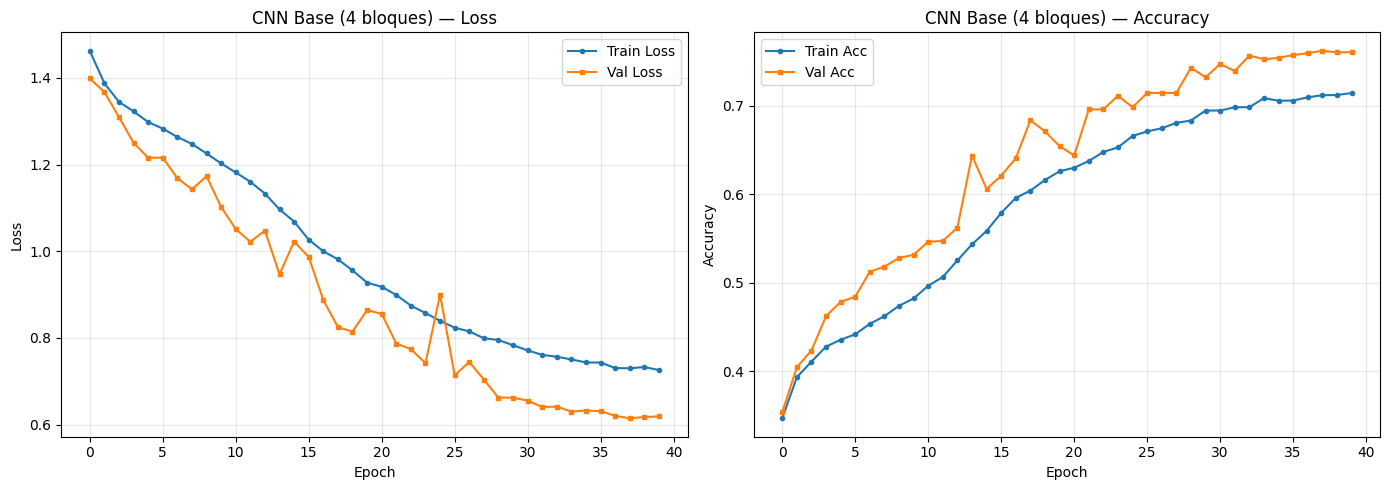

In [5]:
plot_training_history(history_cnn, title="CNN Base (4 bloques)", save_path=FIGURES_DIR / "02_cnn_base_history.png")

## 4. CNN Profunda (6 bloques) — Más capacidad

Se añaden 2 bloques convolucionales adicionales (256→512→512) para evaluar si más profundidad mejora la captura de patrones de defectos.

In [6]:
cnn_deep_model = CNNClassifierDeep(num_classes=5, dropout=0.5)
cnn_deep_params = count_parameters(cnn_deep_model)
print(f"CNN Profunda (6 bloques):")
print(f"  Parametros totales:     {cnn_deep_params['total']:,}")
print(f"  Parametros entrenables: {cnn_deep_params['trainable']:,}")
print(f"\nComparacion:")
print(f"  CNN Base:     {cnn_params['total']:>10,} params")
print(f"  CNN Profunda: {cnn_deep_params['total']:>10,} params")
print(f"  Ratio:        {cnn_deep_params['total']/cnn_params['total']:.1f}x")

CNN Profunda (6 bloques):
  Parametros totales:     4,326,661
  Parametros entrenables: 4,326,661

Comparacion:
  CNN Base:        456,453 params
  CNN Profunda:  4,326,661 params
  Ratio:        9.5x


In [7]:
history_cnn_deep = train_classifier(
    model=cnn_deep_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=40,
    lr=1e-3,
    weight_decay=1e-4,
    class_weights=class_weights,
    device=DEVICE,
    save_dir=MODELS_DIR,
    model_name="cnn_deep",
    patience=10,
    scheduler_type="cosine",
)

Epoch   1/40 | Train Loss: 1.4687 Acc: 0.3349 | Val Loss: 1.4120 Acc: 0.3506 | LR: 1.00e-03 | 237.2s
  Mejor modelo guardado (val_acc=0.3506)


Epoch   2/40 | Train Loss: 1.3001 Acc: 0.4419 | Val Loss: 1.2538 Acc: 0.4852 | LR: 9.98e-04 | 257.6s
  Mejor modelo guardado (val_acc=0.4852)


Epoch   3/40 | Train Loss: 1.1965 Acc: 0.4913 | Val Loss: 1.1922 Acc: 0.4594 | LR: 9.94e-04 | 251.0s


Epoch   4/40 | Train Loss: 1.1377 Acc: 0.5235 | Val Loss: 1.0583 Acc: 0.5670 | LR: 9.86e-04 | 251.2s
  Mejor modelo guardado (val_acc=0.5670)


Epoch   5/40 | Train Loss: 1.0814 Acc: 0.5557 | Val Loss: 1.0371 Acc: 0.6037 | LR: 9.76e-04 | 252.8s
  Mejor modelo guardado (val_acc=0.6037)


...

Epoch  36/40 | Train Loss: 0.3301 Acc: 0.8690 | Val Loss: 0.3023 Acc: 0.8893 | LR: 4.77e-05 | 246.5s


Epoch  37/40 | Train Loss: 0.3324 Acc: 0.8697 | Val Loss: 0.3016 Acc: 0.8918 | LR: 3.42e-05 | 275.0s
  Mejor modelo guardado (val_acc=0.8918)


Epoch  38/40 | Train Loss: 0.3298 Acc: 0.8700 | Val Loss: 0.2972 Acc: 0.8932 | LR: 2.37e-05 | 285.3s
  Mejor modelo guardado (val_acc=0.8932)


Epoch  39/40 | Train Loss: 0.3221 Acc: 0.8730 | Val Loss: 0.2953 Acc: 0.8952 | LR: 1.61e-05 | 261.0s
  Mejor modelo guardado (val_acc=0.8952)


Epoch  40/40 | Train Loss: 0.3222 Acc: 0.8721 | Val Loss: 0.2945 Acc: 0.8950 | LR: 1.15e-05 | 243.4s


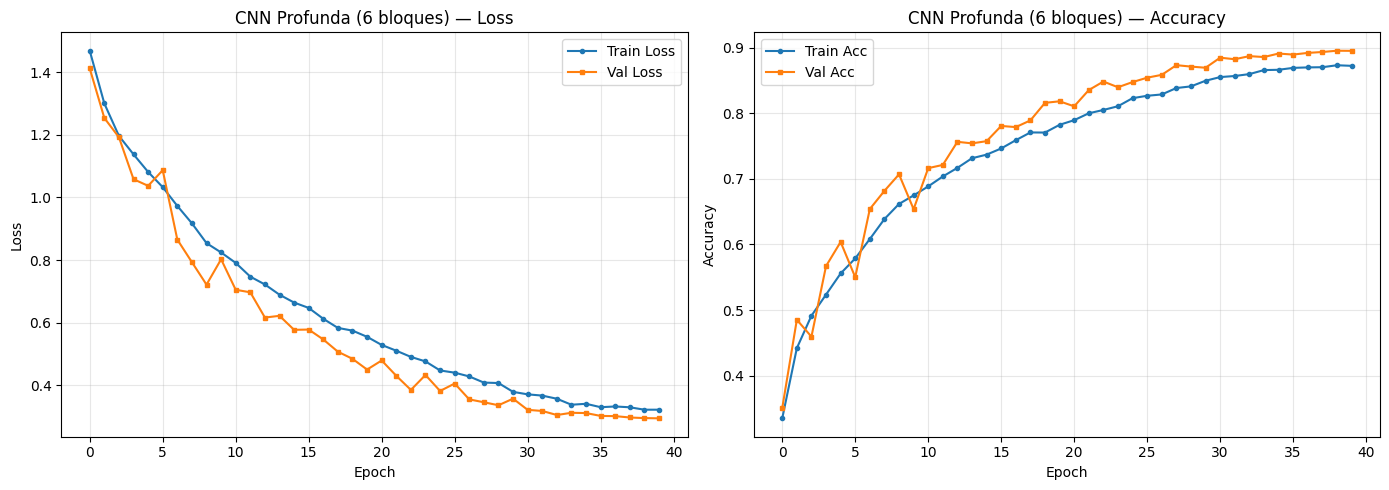

In [8]:
plot_training_history(history_cnn_deep, title="CNN Profunda (6 bloques)", save_path=FIGURES_DIR / "02_cnn_deep_history.png")

## 5. Ablation Study

Evaluamos el impacto de diferentes hiperparámetros en la CNN base:
1. **Número de capas**: 4 bloques vs 6 bloques (ya entrenados arriba)
2. **Dropout**: 0.3 vs 0.5 vs 0.7
3. **Learning rate**: 1e-2 vs 1e-3 vs 1e-4

In [9]:
ablation_results = {}
ablation_results["4-blocks_d0.5_lr1e-3"] = history_cnn
ablation_results["6-blocks_d0.5_lr1e-3"] = history_cnn_deep

for dropout_val in [0.3, 0.7]:
    print(f"\n{'='*60}")
    print(f"Ablation: CNN Base con dropout={dropout_val}")
    print(f"{'='*60}")
    model_abl = CNNClassifier(num_classes=5, dropout=dropout_val)
    hist = train_classifier(
        model=model_abl,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=25,
        lr=1e-3,
        class_weights=class_weights,
        device=DEVICE,
        save_dir=MODELS_DIR,
        model_name=f"cnn_abl_d{dropout_val}",
        patience=7,
        scheduler_type="cosine",
    )
    ablation_results[f"4-blocks_d{dropout_val}_lr1e-3"] = hist

for lr_val in [1e-2, 1e-4]:
    print(f"\n{'='*60}")
    print(f"Ablation: CNN Base con lr={lr_val}")
    print(f"{'='*60}")
    model_abl = CNNClassifier(num_classes=5, dropout=0.5)
    hist = train_classifier(
        model=model_abl,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=25,
        lr=lr_val,
        class_weights=class_weights,
        device=DEVICE,
        save_dir=MODELS_DIR,
        model_name=f"cnn_abl_lr{lr_val}",
        patience=7,
        scheduler_type="cosine",
    )
    ablation_results[f"4-blocks_d0.5_lr{lr_val}"] = hist

print("\nAblation study completado")


Ablation: CNN Base con dropout=0.3


Epoch   1/25 | Train Loss: 1.4337 Acc: 0.3651 | Val Loss: 1.3137 Acc: 0.4682 | LR: 1.00e-03 | 223.4s
  Mejor modelo guardado (val_acc=0.4682)


Epoch   2/25 | Train Loss: 1.3375 Acc: 0.4170 | Val Loss: 1.2817 Acc: 0.4458 | LR: 9.96e-04 | 229.8s


Epoch   3/25 | Train Loss: 1.3027 Acc: 0.4345 | Val Loss: 1.2319 Acc: 0.4600 | LR: 9.84e-04 | 237.7s


Epoch   4/25 | Train Loss: 1.2751 Acc: 0.4503 | Val Loss: 1.2101 Acc: 0.4728 | LR: 9.65e-04 | 276.7s
  Mejor modelo guardado (val_acc=0.4728)


...

Epoch  21/25 | Train Loss: 0.9759 Acc: 0.5962 | Val Loss: 0.8671 Acc: 0.6649 | LR: 1.05e-05 | 197.1s
  Mejor modelo guardado (val_acc=0.6649)


Epoch  22/25 | Train Loss: 0.9671 Acc: 0.6024 | Val Loss: 0.8641 Acc: 0.6555 | LR: 7.12e-06 | 186.2s


Epoch  23/25 | Train Loss: 0.9663 Acc: 0.6054 | Val Loss: 0.8567 Acc: 0.6649 | LR: 4.48e-06 | 184.0s


Epoch  24/25 | Train Loss: 0.9605 Acc: 0.6077 | Val Loss: 0.8495 Acc: 0.6625 | LR: 2.56e-06 | 248.8s


Epoch  25/25 | Train Loss: 0.9583 Acc: 0.6060 | Val Loss: 0.8541 Acc: 0.6639 | LR: 1.39e-06 | 183.1s

Ablation study completado


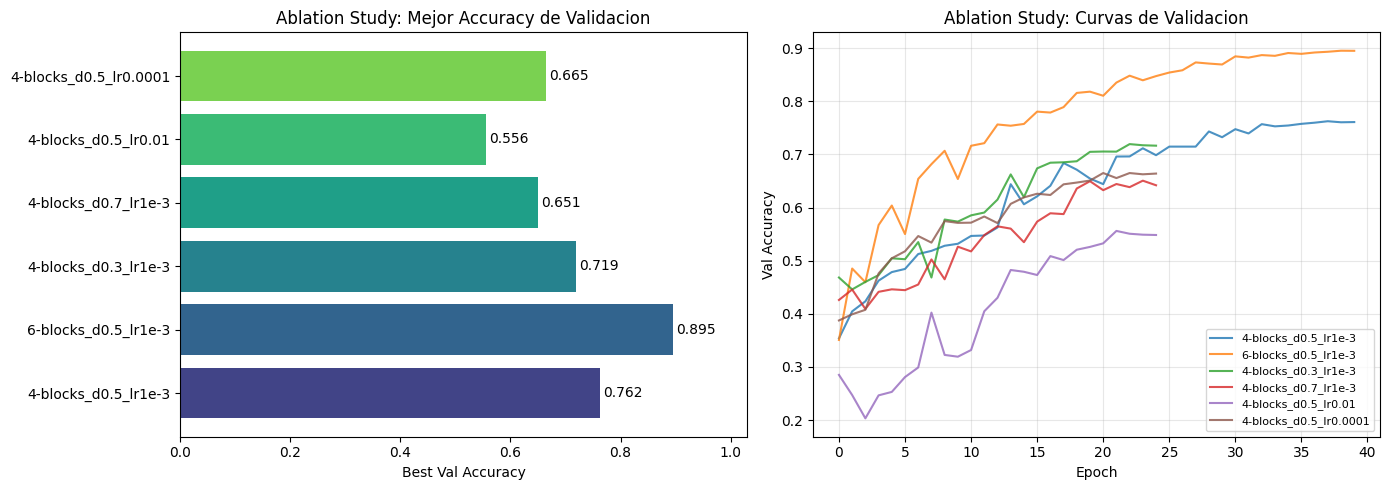

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = list(ablation_results.keys())
best_accs = [ablation_results[c]["best_val_acc"] for c in configs]

ax = axes[0]
bars = ax.barh(configs, best_accs, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(configs))))
ax.set_xlabel("Best Val Accuracy")
ax.set_title("Ablation Study: Mejor Accuracy de Validacion")
for bar, acc in zip(bars, best_accs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{acc:.3f}", va='center', fontsize=10)
ax.set_xlim(0, max(best_accs) * 1.15)

ax = axes[1]
for name, hist in ablation_results.items():
    ax.plot(hist["val_acc"], label=name, alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Val Accuracy")
ax.set_title("Ablation Study: Curvas de Validacion")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Evaluación en Test Set

### 6.1 Mejor CNN (seleccionada del ablation study)

In [11]:
best_config = max(ablation_results, key=lambda k: ablation_results[k]["best_val_acc"])
print(f"Mejor configuracion: {best_config}")
print(f"  Best Val Acc: {ablation_results[best_config]['best_val_acc']:.4f}")

if "6-blocks" in best_config:
    best_cnn = CNNClassifierDeep(num_classes=5, dropout=0.5)
    best_cnn.load_state_dict(torch.load(MODELS_DIR / "cnn_deep_best.pt", weights_only=True))
else:
    best_cnn = CNNClassifier(num_classes=5, dropout=0.5)
    best_cnn.load_state_dict(torch.load(MODELS_DIR / "cnn_base_best.pt", weights_only=True))

best_cnn = best_cnn.to(DEVICE)
best_cnn.eval()

y_true, y_pred, y_proba = get_predictions_with_proba(best_cnn, test_loader, DEVICE)
metrics_cnn = compute_metrics(y_true, y_pred, CLASS_NAMES, y_proba)
print(f"\nMetricas en Test Set:")
for k, v in metrics_cnn.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

Mejor configuracion: 6-blocks_d0.5_lr1e-3
  Best Val Acc: 0.8952

Metricas en Test Set:
  accuracy: 0.8932
  f1_macro: 0.8942
  f1_weighted: 0.8930
  precision_macro: 0.8891
  recall_macro: 0.9001
  roc_auc_macro: 0.9871


### 6.2 Matriz de Confusión y Curvas ROC

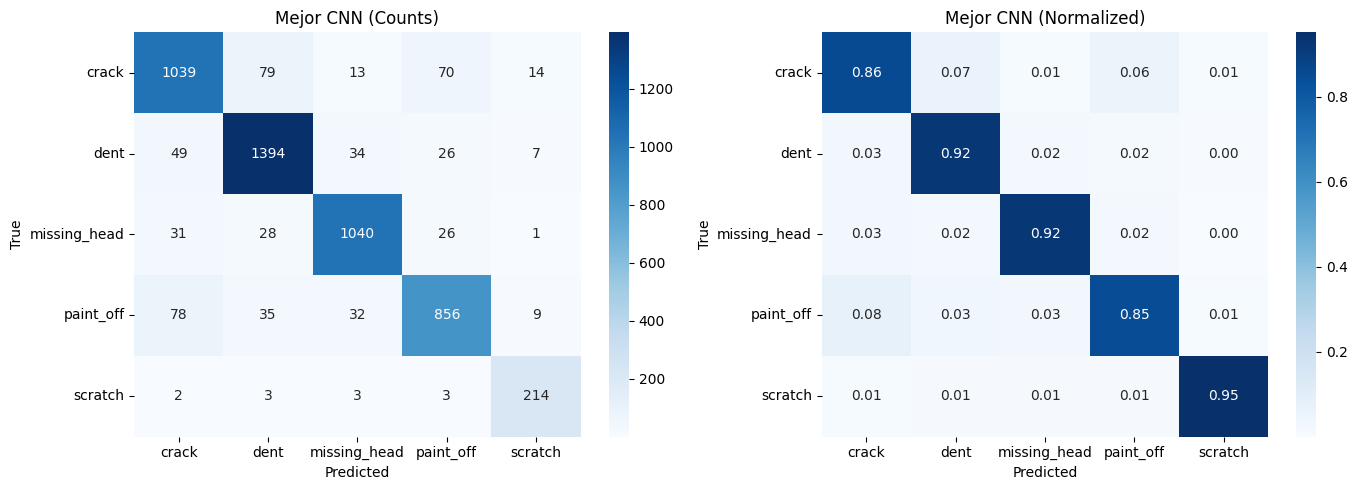

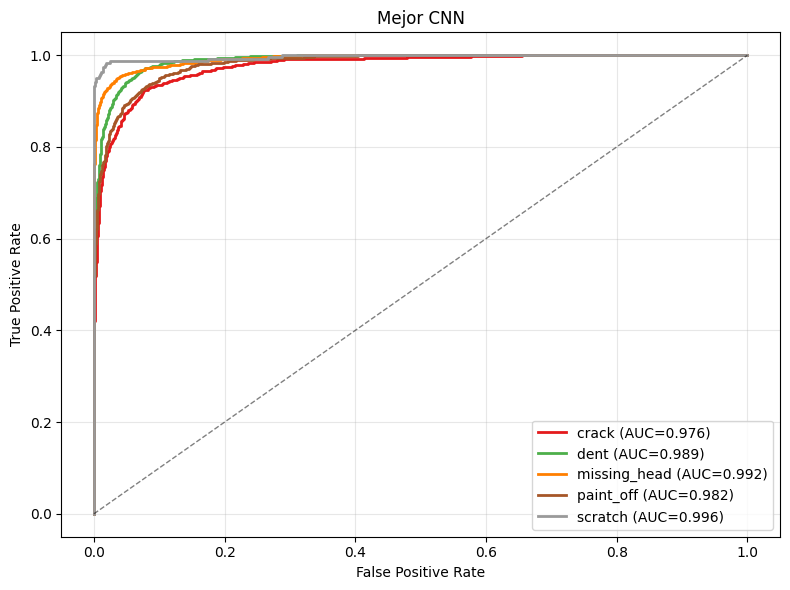

In [12]:
plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, title="Mejor CNN", save_path=FIGURES_DIR / "02_cnn_confusion_matrix.png")
plot_roc_curves(y_true, y_proba, CLASS_NAMES, title="Mejor CNN", save_path=FIGURES_DIR / "02_cnn_roc_curves.png")

### 6.3 Comparación CNN vs MLP Base

    Model Accuracy F1-Macro Precision Recall F1-crack F1-dent F1-missing_head F1-paint_off F1-scratch AUC-Macro
 MLP Base   0.4797   0.4548    0.4514 0.4614   0.4012  0.5189          0.6535       0.3635     0.3372    0.7509
Mejor CNN   0.8932   0.8942    0.8891 0.9001   0.8608  0.9144          0.9253       0.8599     0.9106    0.9871


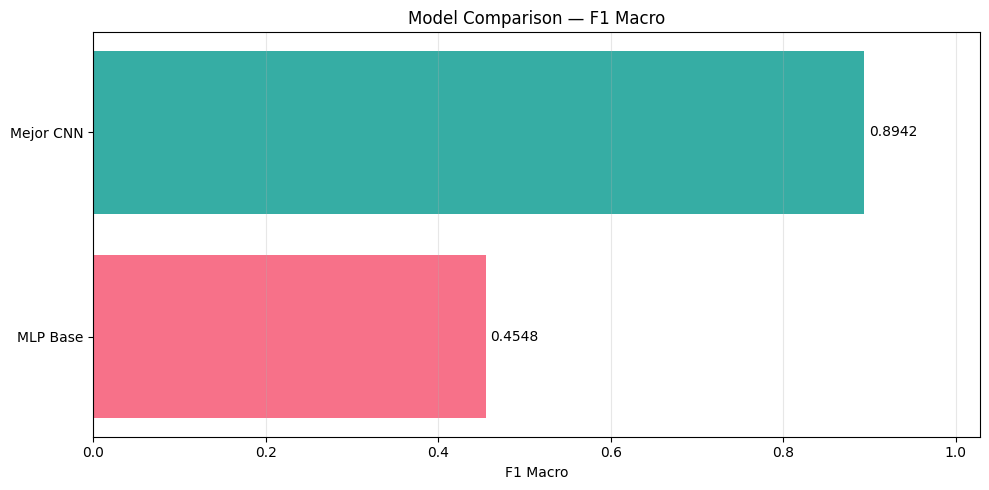

In [13]:
import json

mlp_metrics_path = MODELS_DIR / "mlp_base_metrics.json"
if mlp_metrics_path.exists():
    with open(mlp_metrics_path) as f:
        metrics_mlp = json.load(f)
else:
    print("No se encontraron metricas del MLP. Ejecuta primero Notebook 01.")
    metrics_mlp = {"accuracy": 0.0, "f1_weighted": 0.0, "roc_auc_macro": 0.0}

comparison = {
    "MLP Base": metrics_mlp,
    "Mejor CNN": metrics_cnn,
}
print_comparison_table(comparison, CLASS_NAMES)
plot_model_comparison(comparison, metric="f1_macro", save_path=FIGURES_DIR / "02_cnn_vs_mlp.png")

## 7. Visualización con Grad-CAM

Grad-CAM nos permite ver qué regiones de la imagen son más importantes para la decisión del modelo CNN.

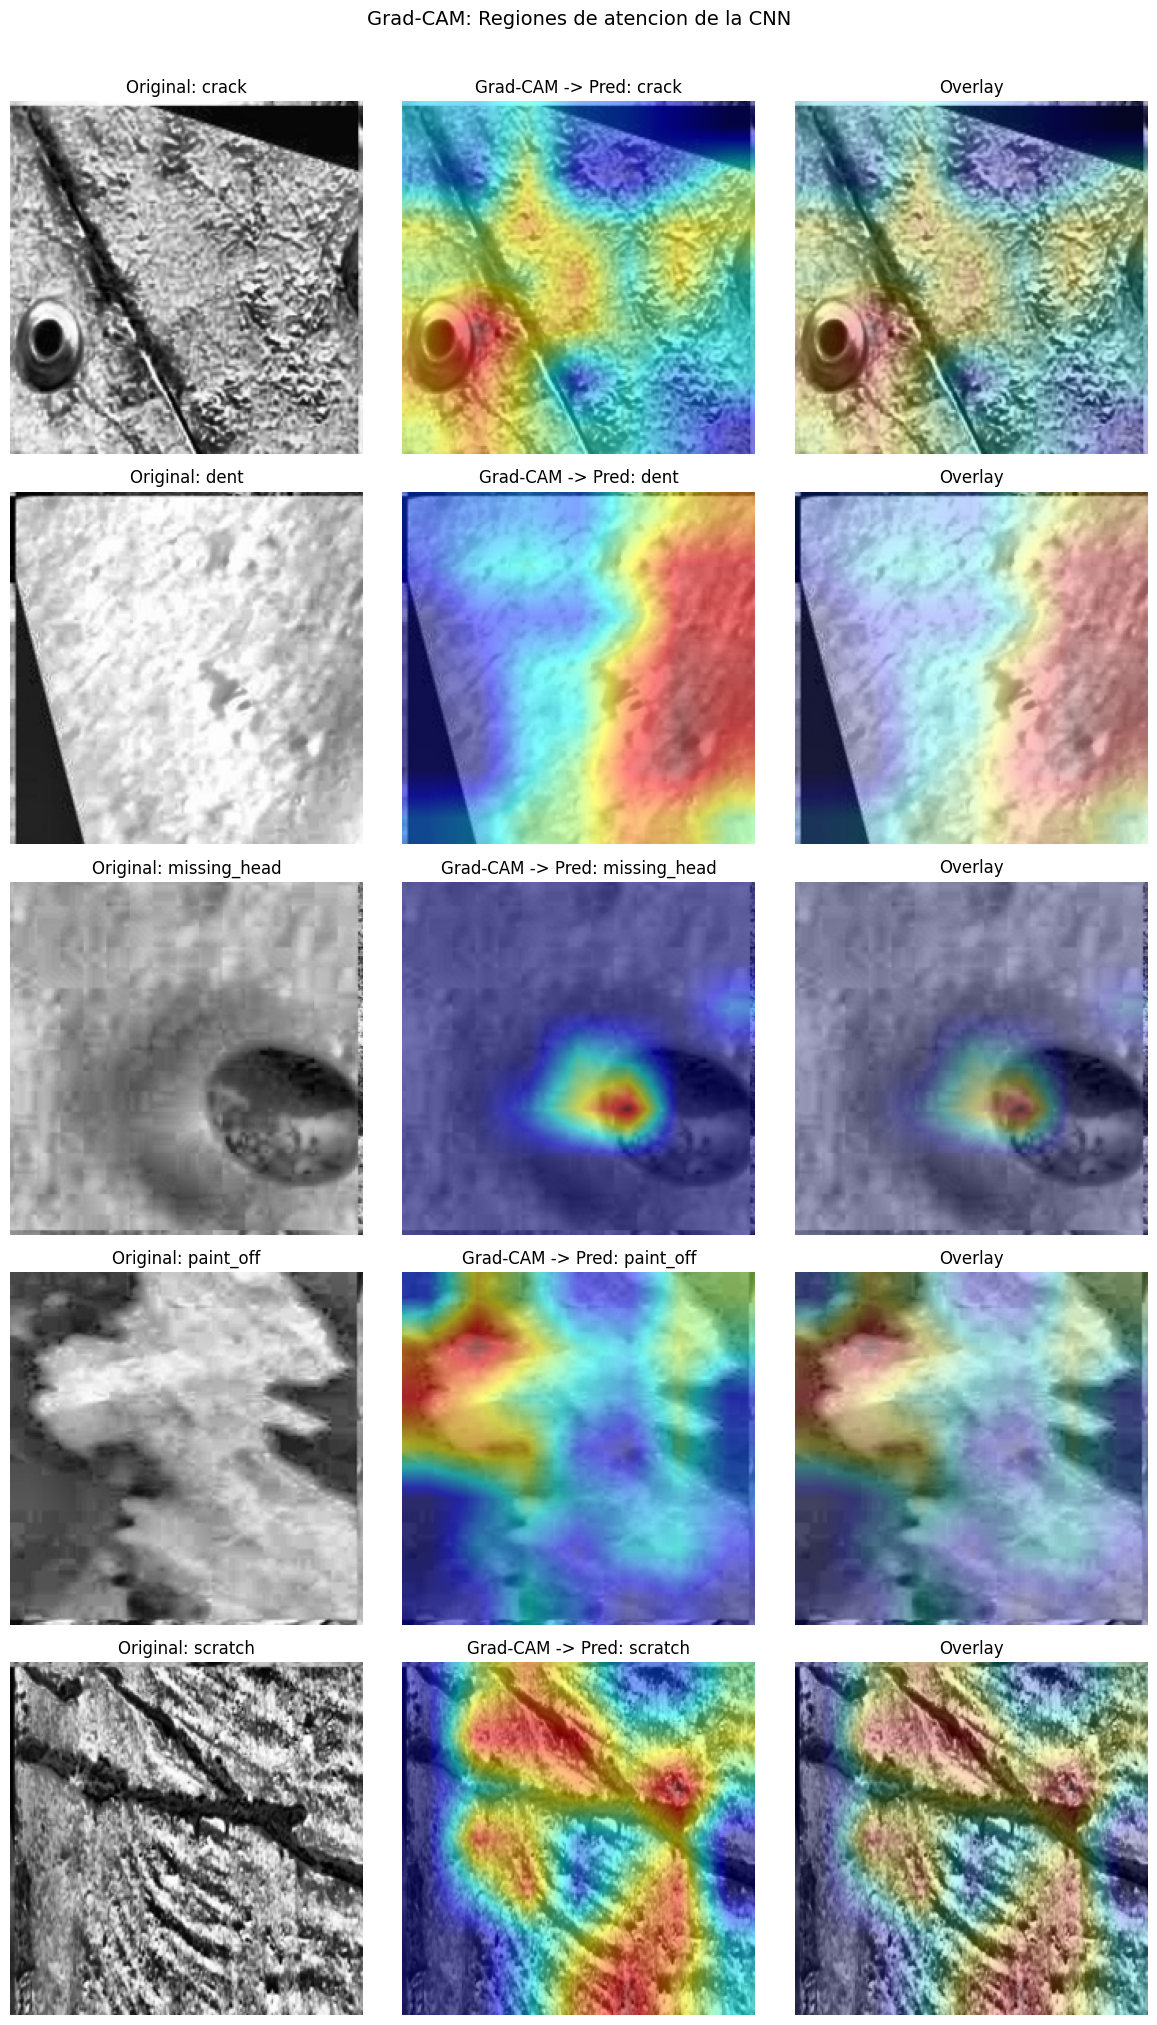

In [14]:
from PIL import Image

test_dataset = test_loader.dataset
samples_per_class = {}
for idx in range(len(test_dataset)):
    img, label = test_dataset[idx]
    if label not in samples_per_class:
        samples_per_class[label] = (test_dataset.df.iloc[idx]["path"], label)
    if len(samples_per_class) == len(CLASS_NAMES):
        break

model_type = "cnn_deep" if "6-blocks" in best_config else "cnn"

fig, axes = plt.subplots(len(samples_per_class), 3, figsize=(12, 4 * len(samples_per_class)))

for i, (label_id, (img_path, label)) in enumerate(sorted(samples_per_class.items())):
    pil_img = Image.open(img_path).convert("RGB")
    cam_image, pred, probs = generate_gradcam(
        best_cnn, pil_img, model_type=model_type, device=DEVICE
    )

    img_resized = np.array(pil_img.resize((224, 224))).astype(np.float32) / 255.0

    axes[i, 0].imshow(img_resized)
    axes[i, 0].set_title(f"Original: {CLASS_NAMES[label_id]}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cam_image)
    axes[i, 1].set_title(f"Grad-CAM -> Pred: {CLASS_NAMES[pred]}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(img_resized)
    axes[i, 2].imshow(cam_image, alpha=0.5)
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis("off")

plt.suptitle("Grad-CAM: Regiones de atencion de la CNN", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_gradcam_cnn.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Guardar Resultados

In [15]:
cnn_metrics_path = MODELS_DIR / "cnn_best_metrics.json"
metrics_json = {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                for k, v in metrics_cnn.items() if k != 'classification_report'}
with open(cnn_metrics_path, 'w') as f:
    json.dump(metrics_json, f, indent=2, default=str)

ablation_summary = {name: {"best_val_acc": h["best_val_acc"]} for name, h in ablation_results.items()}
with open(MODELS_DIR / "ablation_results.json", 'w') as f:
    json.dump(ablation_summary, f, indent=2)

print(f"Metricas CNN guardadas en {cnn_metrics_path}")
print(f"Ablation results guardados")

Metricas CNN guardadas en d:\Documents\Maestria\ML\aircraft-skin-defect-classifier\results\models\cnn_best_metrics.json
Ablation results guardados


## 9. Conclusiones

### Resultados del Ablation Study

| Configuración | Val Accuracy | Observación |
|---------------|-------------|-------------|
| 4 bloques, d=0.5, lr=1e-3 (base) | 0.7624 | Línea base CNN |
| **6 bloques, d=0.5, lr=1e-3** | **0.8952** | **Mejor configuración (+13.28 pp)** |
| 4 bloques, d=0.3, lr=1e-3 | 0.7194 | Menos regularización → overfitting |
| 4 bloques, d=0.7, lr=1e-3 | 0.6505 | Exceso de dropout → underfitting |
| 4 bloques, d=0.5, lr=0.01 | 0.5559 | LR muy alto → inestabilidad |
| 4 bloques, d=0.5, lr=0.0001 | 0.6649 | LR muy bajo → convergencia lenta |

**Hallazgos clave del ablation:**
- **Profundidad es el factor más importante**: 6 bloques supera a 4 bloques por +13.28 pp — más capas capturan jerarquías de features más ricas (bordes → texturas → patrones complejos)
- **Dropout óptimo = 0.5**: d=0.3 causa overfitting (-4.3 pp), d=0.7 mata capacidad de aprendizaje (-11.2 pp)
- **Learning rate crítico**: lr=1e-3 es óptimo; lr=0.01 diverge (-20.7 pp), lr=1e-4 converge muy lento (-9.8 pp)

### Resultados del Mejor Modelo (CNN Deep — 6 bloques) en Test Set

| Métrica | Valor |
|---------|-------|
| **Accuracy** | **0.8932** |
| **F1-Macro** | **0.8942** |
| Precision-Macro | 0.8891 |
| Recall-Macro | 0.9001 |
| ROC-AUC-Macro | 0.9871 |

**F1 por Clase:**
| Clase | F1-Score |
|-------|----------|
| crack | 0.8608 |
| dent | 0.9144 |
| missing_head | **0.9253** (mejor) |
| paint_off | 0.8599 |
| scratch | 0.9106 |

### CNN vs MLP: Impacto de la Estructura Espacial

| Métrica | MLP (E1) | CNN Deep (E2) | Mejora |
|---------|----------|---------------|--------|
| Accuracy | 0.4797 | **0.8932** | **+41.35 pp (+86.2%)** |
| F1-Macro | 0.4548 | **0.8942** | **+43.94 pp (+96.6%)** |
| ROC-AUC | 0.7509 | **0.9871** | +23.62 pp |

- La CNN **casi duplica** la accuracy del MLP, demostrando que preservar las relaciones espaciales es fundamental para clasificar defectos visuales
- Los kernels convolucionales detectan bordes (crack, scratch), texturas (paint_off) y formas circulares (missing_head, dent)
- Grad-CAM confirma que la CNN atiende a las **regiones relevantes del defecto**, no al fondo
- La clase `missing_head` alcanza el F1 más alto (0.9253), consistente con su patrón visual muy distintivo
- La clase `scratch` mejora drásticamente (0.34 → 0.91) gracias a la detección de patrones lineales

### Próximos pasos
- **Etapa 3**: Transfer learning con ResNet50 y ViT — explotar features preentrenadas de ImageNet
- Se espera mejora adicional al transferir conocimiento de millones de imágenes naturales al dominio de inspección aeronáutica